# Estudio de Detección de Spoofing de Voz
Este notebook combina el análisis de detección de ataques Zero-Day (A14) y el estudio de importancia de características para simplificar el modelo.

## 1. Importación de Librerías

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

## 2. Carga y Preparación Global de Datos

In [5]:
# Cargar el dataset
df = pd.read_csv('../../Datos/df_general.csv')

# Definir columnas a excluir de las features
columnas_a_excluir = ['file_name', 'User_ID', 'Spoofing_ID', 'Key']

print(f"Dataset cargado con {len(df)} muestras.")

Dataset cargado con 94632 muestras.


## 3. Experimento: Evaluación contra Ataque Zero-Day (A14)
Entrenamos con ataques conocidos y evaluamos la capacidad de detección del ataque A14 (nunca visto por el modelo).

In [6]:
isolated_spoof_id = 'A14'

# Separar por tipo
df_reales = df[df['Key'] != 'spoof']
df_falsos = df[df['Key'] == 'spoof']

# Muestras del ataque DESCONOCIDO (Van TODAS al test)
falsos_desconocidos_test = df_falsos[df_falsos['Spoofing_ID'] == isolated_spoof_id]
# Muestras de los ataques CONOCIDOS
falsos_conocidos_pool = df_falsos[df_falsos['Spoofing_ID'] != isolated_spoof_id]

# Reparto: 15000 muestras para Train (7.5k reales, 7.k conocidos), resto a Test
reales_train, reales_test = train_test_split(df_reales, train_size=7500, random_state=42)
falsos_conocidos_train, falsos_conocidos_test = train_test_split(
    falsos_conocidos_pool, 
    train_size=7500, 
    stratify=falsos_conocidos_pool['Spoofing_ID'], 
    random_state=42
)

df_train_a14 = pd.concat([reales_train, falsos_conocidos_train]).sample(frac=1, random_state=42)
df_test_a14 = pd.concat([reales_test, falsos_conocidos_test, falsos_desconocidos_test]).sample(frac=1, random_state=42)

X_train_a14 = df_train_a14.drop(columns=columnas_a_excluir)
y_train_a14 = df_train_a14['Key']
X_test_a14 = df_test_a14.drop(columns=columnas_a_excluir)
y_test_a14 = df_test_a14['Key']

# Entrenamiento
rf_a14 = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
rf_a14.fit(X_train_a14, y_train_a14)

# Predicción y Análisis
y_pred_a14 = rf_a14.predict(X_test_a14)
df_test_a14['Prediccion'] = y_pred_a14

print("\n=== RECALL A14 ===")
mask_desconocido = df_test_a14['Spoofing_ID'] == isolated_spoof_id
aciertos_desconocido = sum(df_test_a14[mask_desconocido]['Key'] == df_test_a14[mask_desconocido]['Prediccion'])
total_desconocido = sum(mask_desconocido)
print(f"-> Ataque (A14) bloqueado: {aciertos_desconocido}/{total_desconocido} ({(aciertos_desconocido/total_desconocido)*100:.2f}%)")


=== RECALL A14 ===
-> Ataque (A14) bloqueado: 4834/4914 (98.37%)


## 4. Análisis de Importancia de Características (Modelo Genérico)
Calculamos qué variables son más relevantes usando todos los spoofing_id.

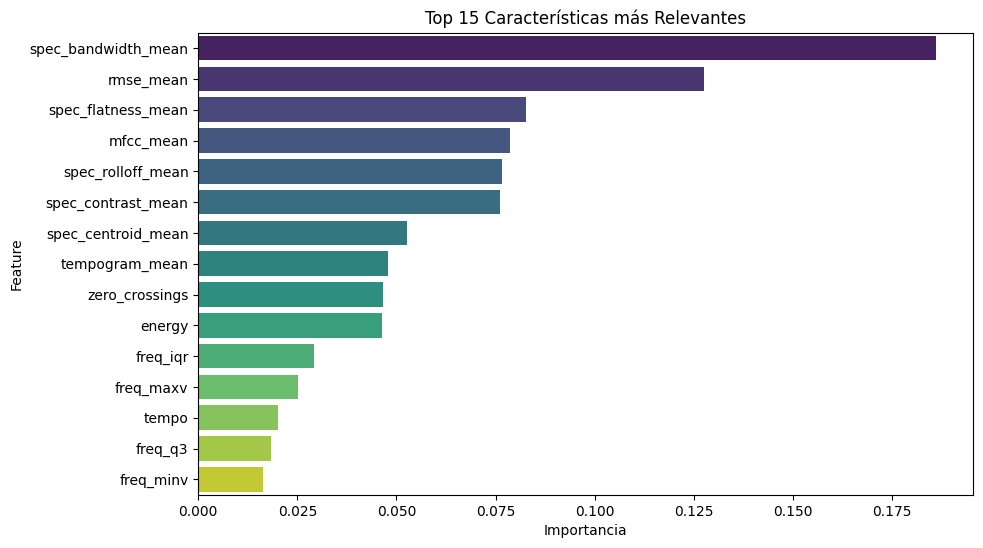

Top 11 Features:
                 Feature  Importancia
0   spec_bandwidth_mean     0.186185
1             rmse_mean     0.127531
2    spec_flatness_mean     0.082689
3             mfcc_mean     0.078566
4     spec_rolloff_mean     0.076696
5    spec_contrast_mean     0.076022
6    spec_centroid_mean     0.052728
7        tempogram_mean     0.047868
8        zero_crossings     0.046601
9                energy     0.046255
10             freq_iqr     0.029080


In [ ]:
# Selección de 15000 muestras balanceadas de TODOS los ataques
reales_train_gen, _ = train_test_split(df[df['Key'] != 'spoof'], train_size=7500, random_state=42)
falsos_train_gen, _ = train_test_split(
    df[df['Key'] == 'spoof'], 
    train_size=7500, 
    stratify=df[df['Key'] == 'spoof']['Spoofing_ID'], 
    random_state=42
)

df_train_gen = pd.concat([reales_train_gen, falsos_train_gen]).sample(frac=1, random_state=42)
X_train_gen = df_train_gen.drop(columns=columnas_a_excluir)
y_train_gen = df_train_gen['Key']

# Entrenamiento para Importancia
rf_gen = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
rf_gen.fit(X_train_gen, y_train_gen)

# Extracción y Gráfico
df_importancia = pd.DataFrame({
    'Feature': X_train_gen.columns,
    'Importancia': rf_gen.feature_importances_
}).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=df_importancia.head(15), hue='Feature', legend=False, palette='viridis')
plt.title('Top 15 Características más Relevantes')
plt.show()

print("Top 11 Features:\n", df_importancia.head(11))

## 5. Modelo Genérico Simplificado
Entrenamiento final usando solo las 6 características más relevantes.

In [8]:
features_top = [
    'spec_bandwidth_mean', 'rmse_mean', 'spec_rolloff_mean', 
    'spec_flatness_mean', 'spec_contrast_mean', 'mfcc_mean'
]

# Usamos el mismo reparto pero filtrando columnas
X_train_simple = df_train_gen[features_top]
# Para el test, usamos todo lo que no esté en train_gen para una evaluación masiva
df_test_gen = df.drop(df_train_gen.index)
X_test_simple = df_test_gen[features_top]
y_test_simple = df_test_gen['Key']

# Entrenamiento
rf_simple = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
rf_simple.fit(X_train_simple, y_train_gen)

# Resultados
y_pred_simple = rf_simple.predict(X_test_simple)
print("\n=== RESULTADOS MODELO SIMPLIFICADO ===")
print(classification_report(y_test_simple, y_pred_simple))
print(f"Accuracy Global: {accuracy_score(y_test_simple, y_pred_simple):.4f}")


=== RESULTADOS MODELO SIMPLIFICADO ===
              precision    recall  f1-score   support

    bonafide       0.03      0.86      0.05       450
       spoof       1.00      0.82      0.90     79182

    accuracy                           0.82     79632
   macro avg       0.51      0.84      0.47     79632
weighted avg       0.99      0.82      0.89     79632

Accuracy Global: 0.8175


## 6. Modelo Genérico con ruido

In [9]:
print("\n--- TEST 3: RESISTENCIA AL RUIDO (ENFOQUE F1-SCORE) ---")

# 1. Calculamos el F1-Score original (sin ruido)
# Usamos 'weighted' para tener en cuenta el desbalance entre voces reales y falsas
f1_original = f1_score(y_test_simple, y_pred_simple, average='weighted')

# 2. Añadimos un 5% de ruido aleatorio a las características del test simplificado
X_test_noisy = X_test_simple + 0.05 * np.random.normal(size=X_test_simple.shape)

# 3. Hacemos las predicciones del modelo sobre los datos ruidosos
y_pred_noisy = rf_simple.predict(X_test_noisy)

# 4. Calculamos el F1-Score resultante tras el ruido
f1_ruido = f1_score(y_test_simple, y_pred_noisy, average='weighted')

# 5. Mostramos los resultados
print(f"F1-Score original (audio limpio): {f1_original:.4f}")
print(f"F1-Score con datos ruidosos:      {f1_ruido:.4f}")
print("-" * 45)
print(f"Caída de efectividad (F1-Score):  {f1_original - f1_ruido:.4f}")


--- TEST 3: RESISTENCIA AL RUIDO (ENFOQUE F1-SCORE) ---
F1-Score original (audio limpio): 0.8943
F1-Score con datos ruidosos:      0.9620
---------------------------------------------
Caída de efectividad (F1-Score):  -0.0677
